<a href="https://colab.research.google.com/github/pengin-cmd/my-colab-notebooks/blob/main/%E3%82%B3%E3%83%B3%E3%83%9A2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!pip install xgboost catboost optuna lightgbm

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 97.1/97.1 MB 8.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 425.6/425.6 kB 25.5 MB/s eta 0:00:00


In [ ]:
!pip install optuna

In [ ]:
pip install lifetimes

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 584.2/584.2 kB 3.5 MB/s eta 0:00:00



--- [1. Optuna パラメータ最適化 (LGBM, XGBoost, CatBoost) - 拡張版] ---
>> Tuning LightGBM...
>> Tuning XGBoost...
>> Tuning CatBoost...

💡 理想の学習回数 - LGBM: 162回 | XGBoost: 1161回 | CatBoost: 483回

--- [2. 学習フェーズ開始 (LGBM, XGBoost, CatBoost)] ---
>> Running Seed: 42...
>> Running Seed: 2023...
>> Running Seed: 777...
>> Running Seed: 888...
>> Running Seed: 1234...
>> Running Seed: 314...
>> Running Seed: 999...
✅ 学習完了: 最終 OOF AUC: 0.8729

🏆 最終ローカルCVスコア (ROC AUC): 0.8729
📉 最終ローカル損失 (Log Loss): 0.3378

--- [3. 予測フェーズ開始] ---
✅ 予測完了: 計 105 個のモデルによるアンサンブル予測を実行しました。

--- [4. エラー分析 (損失原因の特定)] ---
▼ 全体のエラー件数 (is_error = 1): 247 件 / 1568 件

▼ 損失原因度ランキング トップ5:
                    Feature  Error_Importance
0            recent_loyalty         43.362793
1   days_since_registration         19.678353
2           spend_wines_log          8.515764
3  days_since_last_purchase          7.293212
4           discount_hunter          5.352291

--- [5. 特徴量重要度の算出] ---


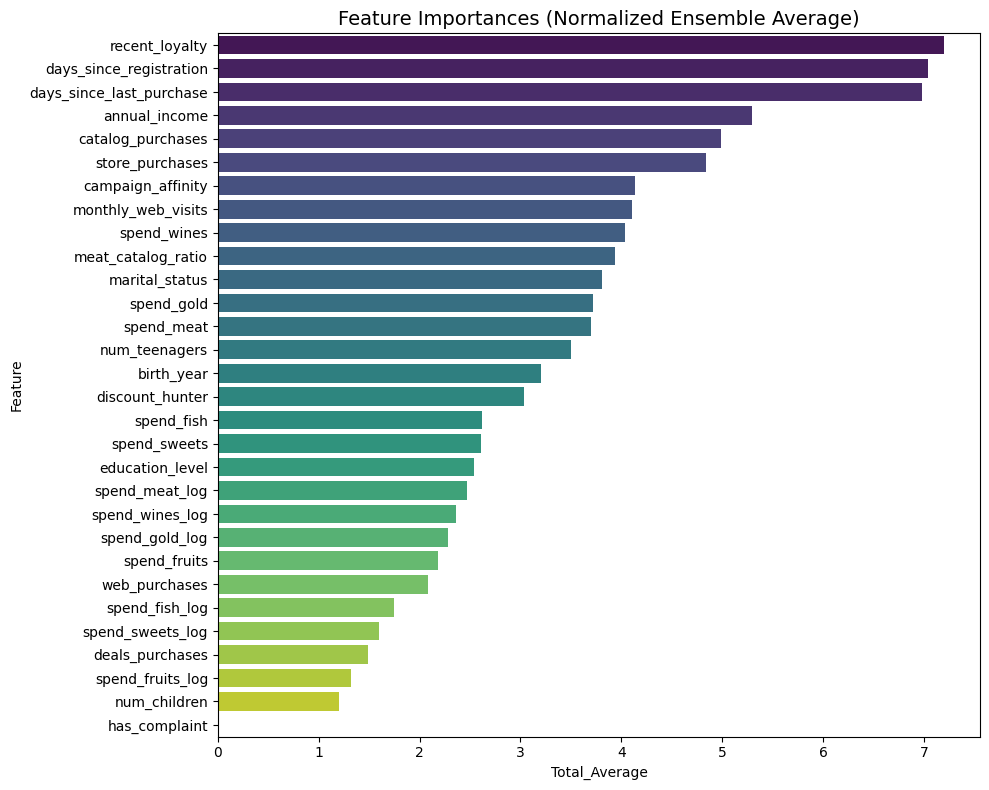


✅ 全工程完了: 'final_submission_trinity_tuned.csv' を出力しました！


In [18]:
import pandas as pd
import numpy as np
import warnings
import optuna
from sklearn.model_selection import StratifiedKFold
from sklearn.preprocessing import OrdinalEncoder, MinMaxScaler
from sklearn.metrics import roc_auc_score, log_loss
from sklearn.tree import DecisionTreeClassifier, export_text
from lightgbm import LGBMClassifier, early_stopping
from xgboost import XGBClassifier
from catboost import CatBoostClassifier
import matplotlib.pyplot as plt
import seaborn as sns

warnings.filterwarnings('ignore')

# ==========================================
# 0. 絶対にリークしない事前処理
# ==========================================
def preprocess_safe_row_wise(df):
    df = df.copy()
    base_date = pd.to_datetime('2015-01-01')

    if 'registration_date' in df.columns:
        df['days_since_registration'] = (base_date - pd.to_datetime(df['registration_date'])).dt.days
        df = df.drop('registration_date', axis=1)

    if all(c in df.columns for c in ['spend_wines', 'spend_meat', 'days_since_last_purchase']):
        raw_loyalty = (df['spend_wines'] + df['spend_meat']) / (df['days_since_last_purchase'] + 1)
        df['recent_loyalty'] = np.log1p(raw_loyalty)

    if all(c in df.columns for c in ['spend_meat', 'catalog_purchases']):
        raw_meat_ratio = df['spend_meat'] / (df['catalog_purchases'] + 1)
        df['meat_catalog_ratio'] = np.log1p(raw_meat_ratio)

    if all(c in df.columns for c in ['deals_purchases', 'store_purchases', 'web_purchases', 'catalog_purchases']):
        total_purchases = df['store_purchases'] + df['web_purchases'] + df['catalog_purchases']
        df['discount_hunter'] = df['deals_purchases'] / (total_purchases + 1)

        if 'recent_loyalty' in df.columns:
            df['campaign_affinity'] = df['recent_loyalty'] * df['discount_hunter']

    spend_cols = [c for c in df.columns if c.startswith('spend_')]
    for col in spend_cols:
        df[col + '_log'] = np.log1p(df[col])

    return df

# ==========================================
# 1. Optuna (3モデルのパラメータ【超広範囲】チューニング)
# ==========================================
def tune_all_models_with_optuna(X_raw, y, n_trials=15):
    print("\n--- [1. Optuna パラメータ最適化 (LGBM, XGBoost, CatBoost) - 拡張版] ---")
    optuna.logging.set_verbosity(optuna.logging.WARNING)

    ratio = float(np.sum(y == 0)) / np.sum(y == 1)
    categorical_cols = ['education_level', 'marital_status']

    # -----------------------
    # ① LightGBM Tuning (拡張)
    # -----------------------
    print(">> Tuning LightGBM...")
    def lgb_objective(trial):
        params = {
            'random_state': 42,
            'n_estimators': 2000,
            'learning_rate': trial.suggest_float('learning_rate', 0.005, 0.2, log=True),
            'max_depth': trial.suggest_int('max_depth', 3, 10),
            'num_leaves': trial.suggest_int('num_leaves', 15, 127),
            'min_child_samples': trial.suggest_int('min_child_samples', 5, 100), # 🌟追加：過学習防止
            'subsample': trial.suggest_float('subsample', 0.5, 1.0),             # 🌟追加：行のサンプリング率
            'colsample_bytree': trial.suggest_float('colsample_bytree', 0.5, 1.0), # 🌟追加：列のサンプリング率
            'reg_alpha': trial.suggest_float('reg_alpha', 1e-8, 10.0, log=True),   # 🌟追加：L1正則化
            'reg_lambda': trial.suggest_float('reg_lambda', 1e-8, 10.0, log=True), # 🌟追加：L2正則化
            'class_weight': 'balanced',
            'verbose': -1
        }
        skf = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)
        fold_best_iters = []
        oof = np.zeros(len(X_raw))

        for tr_idx, va_idx in skf.split(X_raw, y):
            X_tr, y_tr = X_raw.iloc[tr_idx].copy(), y.iloc[tr_idx]
            X_va, y_va = X_raw.iloc[va_idx].copy(), y.iloc[va_idx]

            med = X_tr['annual_income'].median()
            X_tr['annual_income'] = X_tr['annual_income'].fillna(med)
            X_va['annual_income'] = X_va['annual_income'].fillna(med)

            enc = OrdinalEncoder(handle_unknown='use_encoded_value', unknown_value=-1)
            X_tr[categorical_cols] = enc.fit_transform(X_tr[categorical_cols])
            X_va[categorical_cols] = enc.transform(X_va[categorical_cols])

            model = LGBMClassifier(**params)
            model.fit(X_tr, y_tr, eval_set=[(X_va, y_va)], callbacks=[early_stopping(stopping_rounds=30, verbose=False)])
            oof[va_idx] = model.predict_proba(X_va)[:, 1]
            fold_best_iters.append(model.best_iteration_)

        trial.set_user_attr('optimal_iterations', int(np.mean(fold_best_iters)))
        return roc_auc_score(y, oof)

    lgb_study = optuna.create_study(direction='maximize')
    lgb_study.optimize(lgb_objective, n_trials=n_trials)
    lgb_best = lgb_study.best_params
    lgb_best.update({'random_state': 42, 'n_estimators': lgb_study.best_trial.user_attrs['optimal_iterations'], 'class_weight': 'balanced', 'verbose': -1})

    # -----------------------
    # ② XGBoost Tuning (拡張)
    # -----------------------
    print(">> Tuning XGBoost...")
    def xgb_objective(trial):
        params = {
            'random_state': 42,
            'n_estimators': 2000,
            'learning_rate': trial.suggest_float('learning_rate', 0.005, 0.2, log=True),
            'max_depth': trial.suggest_int('max_depth', 3, 10),
            'min_child_weight': trial.suggest_int('min_child_weight', 1, 20),      # 🌟追加：最小子ノード重み
            'gamma': trial.suggest_float('gamma', 1e-8, 1.0, log=True),             # 🌟追加：木の分岐ペナルティ
            'subsample': trial.suggest_float('subsample', 0.5, 1.0),
            'colsample_bytree': trial.suggest_float('colsample_bytree', 0.5, 1.0),
            'reg_alpha': trial.suggest_float('reg_alpha', 1e-8, 10.0, log=True),   # 🌟追加：L1正則化
            'reg_lambda': trial.suggest_float('reg_lambda', 1e-8, 10.0, log=True), # 🌟追加：L2正則化
            'scale_pos_weight': ratio,
            'eval_metric': 'logloss',
            'early_stopping_rounds': 30
        }
        skf = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)
        fold_best_iters = []
        oof = np.zeros(len(X_raw))

        for tr_idx, va_idx in skf.split(X_raw, y):
            X_tr, y_tr = X_raw.iloc[tr_idx].copy(), y.iloc[tr_idx]
            X_va, y_va = X_raw.iloc[va_idx].copy(), y.iloc[va_idx]

            med = X_tr['annual_income'].median()
            X_tr['annual_income'] = X_tr['annual_income'].fillna(med)
            X_va['annual_income'] = X_va['annual_income'].fillna(med)

            enc = OrdinalEncoder(handle_unknown='use_encoded_value', unknown_value=-1)
            X_tr[categorical_cols] = enc.fit_transform(X_tr[categorical_cols])
            X_va[categorical_cols] = enc.transform(X_va[categorical_cols])

            model = XGBClassifier(**params)
            model.fit(X_tr, y_tr, eval_set=[(X_va, y_va)], verbose=False)
            oof[va_idx] = model.predict_proba(X_va)[:, 1]
            fold_best_iters.append(model.best_iteration)

        trial.set_user_attr('optimal_iterations', int(np.mean(fold_best_iters)))
        return roc_auc_score(y, oof)

    xgb_study = optuna.create_study(direction='maximize')
    xgb_study.optimize(xgb_objective, n_trials=n_trials)
    xgb_best = xgb_study.best_params
    xgb_best.update({'random_state': 42, 'n_estimators': xgb_study.best_trial.user_attrs['optimal_iterations'], 'scale_pos_weight': ratio, 'eval_metric': 'logloss'})

    # -----------------------
    # ③ CatBoost Tuning (拡張)
    # -----------------------
    print(">> Tuning CatBoost...")
    def cat_objective(trial):
        params = {
            'random_state': 42,
            'iterations': 2000,
            'learning_rate': trial.suggest_float('learning_rate', 0.005, 0.2, log=True),
            'depth': trial.suggest_int('depth', 4, 10),
            'l2_leaf_reg': trial.suggest_float('l2_leaf_reg', 1e-3, 10.0, log=True),
            'random_strength': trial.suggest_float('random_strength', 1e-9, 10.0, log=True), # 🌟追加：木の分岐スコアのノイズ
            'bagging_temperature': trial.suggest_float('bagging_temperature', 0.0, 1.0), # 🌟追加：サンプリングのランダム度
            'border_count': trial.suggest_int('border_count', 32, 255),                  # 🌟追加：数値特徴量のビン数
            'auto_class_weights': 'Balanced',
            'verbose': False,
            'early_stopping_rounds': 30
        }
        skf = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)
        fold_best_iters = []
        oof = np.zeros(len(X_raw))

        for tr_idx, va_idx in skf.split(X_raw, y):
            X_tr, y_tr = X_raw.iloc[tr_idx].copy(), y.iloc[tr_idx]
            X_va, y_va = X_raw.iloc[va_idx].copy(), y.iloc[va_idx]

            med = X_tr['annual_income'].median()
            X_tr['annual_income'] = X_tr['annual_income'].fillna(med)
            X_va['annual_income'] = X_va['annual_income'].fillna(med)

            X_tr[categorical_cols] = X_tr[categorical_cols].astype(str)
            X_va[categorical_cols] = X_va[categorical_cols].astype(str)

            model = CatBoostClassifier(**params, cat_features=categorical_cols)
            model.fit(X_tr, y_tr, eval_set=[(X_va, y_va)], verbose=False)
            oof[va_idx] = model.predict_proba(X_va)[:, 1]
            fold_best_iters.append(model.get_best_iteration())

        trial.set_user_attr('optimal_iterations', int(np.mean(fold_best_iters)))
        return roc_auc_score(y, oof)

    cat_study = optuna.create_study(direction='maximize')
    cat_study.optimize(cat_objective, n_trials=n_trials)
    cat_best = cat_study.best_params
    cat_best.update({'random_state': 42, 'iterations': cat_study.best_trial.user_attrs['optimal_iterations'], 'auto_class_weights': 'Balanced', 'verbose': False})

    print(f"\n💡 理想の学習回数 - LGBM: {lgb_best['n_estimators']}回 | XGBoost: {xgb_best['n_estimators']}回 | CatBoost: {cat_best['iterations']}回")
    return lgb_best, xgb_best, cat_best

# ==========================================
# 2. 学習フェーズ (Train & Validate)
# ==========================================
def train_models(X_raw, y, lgb_params, xgb_params, cat_params, seeds=[42, 2023, 777], n_splits=5):
    print(f"\n--- [2. 学習フェーズ開始 (LGBM, XGBoost, CatBoost)] ---")
    artifacts = []
    oof_preds_ensemble = np.zeros(len(X_raw))
    categorical_cols = ['education_level', 'marital_status']

    for seed in seeds:
        print(f">> Running Seed: {seed}...")
        skf = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=seed)
        oof_seed = np.zeros(len(X_raw))

        for fold, (train_idx, val_idx) in enumerate(skf.split(X_raw, y)):
            X_tr, y_tr = X_raw.iloc[train_idx].copy(), y.iloc[train_idx]
            X_va, y_va = X_raw.iloc[val_idx].copy(), y.iloc[val_idx]

            X_tr_cat = X_tr.copy()
            X_va_cat = X_va.copy()

            X_tr_cat[categorical_cols] = X_tr_cat[categorical_cols].astype(str)
            X_va_cat[categorical_cols] = X_va_cat[categorical_cols].astype(str)

            income_median = X_tr['annual_income'].median()
            X_tr['annual_income'] = X_tr['annual_income'].fillna(income_median)
            X_va['annual_income'] = X_va['annual_income'].fillna(income_median)
            X_tr_cat['annual_income'] = X_tr_cat['annual_income'].fillna(income_median)
            X_va_cat['annual_income'] = X_va_cat['annual_income'].fillna(income_median)

            encoder = OrdinalEncoder(handle_unknown='use_encoded_value', unknown_value=-1)
            X_tr[categorical_cols] = encoder.fit_transform(X_tr[categorical_cols])
            X_va[categorical_cols] = encoder.transform(X_va[categorical_cols])

            lgb_p = lgb_params.copy()
            lgb_p['random_state'] = seed

            xgb_p = xgb_params.copy()
            xgb_p['random_state'] = seed

            cat_p = cat_params.copy()
            cat_p['random_state'] = seed

            models = {
                'LightGBM': LGBMClassifier(**lgb_p),
                'XGBoost': XGBClassifier(**xgb_p),
                'CatBoost': CatBoostClassifier(**cat_p, cat_features=categorical_cols)
            }

            fold_val_preds = np.zeros(len(X_va))
            for name, model in models.items():
                if name == 'LightGBM':
                    model.fit(X_tr, y_tr)
                    fold_val_preds += model.predict_proba(X_va)[:, 1] / len(models)
                elif name == 'XGBoost':
                    model.fit(X_tr, y_tr, verbose=False)
                    fold_val_preds += model.predict_proba(X_va)[:, 1] / len(models)
                elif name == 'CatBoost':
                    model.fit(X_tr_cat, y_tr, verbose=False)
                    fold_val_preds += model.predict_proba(X_va_cat)[:, 1] / len(models)

            oof_seed[val_idx] = fold_val_preds

            artifacts.append({
                'seed': seed,
                'fold': fold,
                'preprocessors': {'income_median': income_median, 'encoder': encoder, 'cat_cols': categorical_cols},
                'models': models,
                'feature_names': list(X_tr.columns)
            })

        oof_preds_ensemble += oof_seed / len(seeds)

    print(f"✅ 学習完了: 最終 OOF AUC: {roc_auc_score(y, oof_preds_ensemble):.4f}")
    return artifacts, oof_preds_ensemble

# ==========================================
# 3. 予測フェーズ (Predict)
# ==========================================
def predict_models(X_test_raw, artifacts):
    print("\n--- [3. 予測フェーズ開始] ---")
    final_test_preds = np.zeros(len(X_test_raw))
    total_models = 0

    for artifact in artifacts:
        X_te = X_test_raw.copy()
        X_te_cat = X_test_raw.copy()

        preps = artifact['preprocessors']
        models = artifact['models']

        X_te['annual_income'] = X_te['annual_income'].fillna(preps['income_median'])
        X_te_cat['annual_income'] = X_te_cat['annual_income'].fillna(preps['income_median'])

        X_te_cat[preps['cat_cols']] = X_te_cat[preps['cat_cols']].astype(str)
        X_te[preps['cat_cols']] = preps['encoder'].transform(X_te[preps['cat_cols']])

        for name, model in models.items():
            if name == 'CatBoost':
                final_test_preds += model.predict_proba(X_te_cat)[:, 1]
            else:
                final_test_preds += model.predict_proba(X_te)[:, 1]
            total_models += 1

    final_test_preds /= total_models
    print(f"✅ 予測完了: 計 {total_models} 個のモデルによるアンサンブル予測を実行しました。")
    return final_test_preds

# ==========================================
# 4. & 5. 可視化関数
# ==========================================
def analyze_error_patterns(X_raw, y, oof_preds):
    print("\n--- [4. エラー分析 (損失原因の特定)] ---")
    error_df = X_raw.copy()
    error_df['target'] = y
    error_df['pred_class'] = (oof_preds >= 0.5).astype(int)
    error_df['is_error'] = (error_df['target'] != error_df['pred_class']).astype(int)
    print(f"▼ 全体のエラー件数 (is_error = 1): {error_df['is_error'].sum()} 件 / {len(error_df)} 件")

    X_error = X_raw.copy()
    X_error['annual_income'] = X_error['annual_income'].fillna(X_error['annual_income'].median())
    cols = ['education_level', 'marital_status']
    X_error[cols] = OrdinalEncoder(handle_unknown='use_encoded_value', unknown_value=-1).fit_transform(X_error[cols])

    error_model = DecisionTreeClassifier(max_depth=4, random_state=42, class_weight='balanced')
    error_model.fit(X_error, error_df['is_error'])

    error_importance = pd.DataFrame({'Feature': X_error.columns, 'Error_Importance': error_model.feature_importances_ * 100}).sort_values(by='Error_Importance', ascending=False).reset_index(drop=True)
    print("\n▼ 損失原因度ランキング トップ5:")
    print(error_importance.head(5))
    return error_importance

def plot_feature_importances(artifacts):
    print("\n--- [5. 特徴量重要度の算出] ---")
    f_names = artifacts[0]['feature_names']
    importance_df = pd.DataFrame({'Feature': f_names})
    total_imps = np.zeros(len(f_names))
    total_models = 0
    scaler = MinMaxScaler()

    for art in artifacts:
        for name, model in art['models'].items():
            raw_imp = model.feature_importances_
            scaled_imp = scaler.fit_transform(raw_imp.reshape(-1, 1)).flatten()
            total_imps += scaled_imp
            total_models += 1

    importance_df['Total_Average'] = (total_imps / total_models)
    importance_df['Total_Average'] = (importance_df['Total_Average'] / importance_df['Total_Average'].sum()) * 100
    importance_df = importance_df.sort_values(by='Total_Average', ascending=False).reset_index(drop=True)

    plt.figure(figsize=(10, 8))
    sns.barplot(x='Total_Average', y='Feature', data=importance_df, palette='viridis')
    plt.title('Feature Importances (Normalized Ensemble Average)', fontsize=14)
    plt.tight_layout()
    plt.show()

# ==========================================
# メイン実行ブロック
# ==========================================
if __name__ == "__main__":
    train_data = pd.read_csv('train.csv')
    test_data = pd.read_csv('test.csv')

    train_df = preprocess_safe_row_wise(train_data)
    test_df = preprocess_safe_row_wise(test_data)

    X_raw = train_df.drop(['customer_id', 'target'], axis=1)
    y = train_df['target']
    X_test_raw = test_df.drop(['customer_id'], axis=1, errors='ignore')

    # 🌟 各探索空間を広げたため、もし時間に余裕があれば n_trials=20〜30 に増やすと更にスコアが伸びます
    best_lgb_params, best_xgb_params, best_cat_params = tune_all_models_with_optuna(X_raw, y, n_trials=15)

    # 🌟 縁起の良い数字や素数を散りばめた7つのシードを用意（数は5〜10個がおすすめ）
    heavy_seeds = [42, 2023, 777, 888, 1234, 314, 999]

    # 🌟 seeds引数に渡すだけ！
    artifacts, oof_predictions = train_models(
        X_raw, y,
        best_lgb_params, best_xgb_params, best_cat_params,
        seeds=heavy_seeds
    )

    # ==========================================
    # 🌟 追加：最終的なローカルのCVスコアと損失を求めて出力
    # ==========================================
    final_cv_auc = roc_auc_score(y, oof_predictions)
    final_cv_loss = log_loss(y, oof_predictions)

    print(f"\n🏆 最終ローカルCVスコア (ROC AUC): {final_cv_auc:.4f}")
    print(f"📉 最終ローカル損失 (Log Loss): {final_cv_loss:.4f}")
    # ==========================================

    final_predictions = predict_models(X_test_raw, artifacts)

    analyze_error_patterns(X_raw, y, oof_predictions)
    plot_feature_importances(artifacts)

    submission = pd.DataFrame({'customer_id': test_data['customer_id'], 'target': final_predictions})
    submission.to_csv('final_submission_trinity_tuned.csv', index=False)
    print("\n✅ 全工程完了: 'final_submission_trinity_tuned.csv' を出力しました！")